In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
aceticacid,60.05,2.77367,2.967108595,184.2518865,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,aceticacid,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
aceticacid,H,aceticacid,e,2437.161077,0.117403
co2,H,co2,e,0,0
aceticacid,H,co2,e,1218.58,0
aceticacid,e,co2,H,1218.58,0
"""

model = PCSAFT(["co2", "aceticacid"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 178.5893144699613; 178.5893144699613 184.2518865]
[2.785e-10 2.8760542975000003e-10; 2.8760542975000003e-10 2.9671085950000004e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 298.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 298.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 80.,
        :upper   => 300.0,
        :guess   => 179.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 300.0, :param => :epsilon, :indices => (1, 2), :guess => 179.0, :lower => 80.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_aceticacid.csv")
fix_line_endings("vley_aceticacid.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_aceticacid.csv"
        "vley_aceticacid.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_aceticacid.csv
Fixed: vley_aceticacid.csv
Initial objective value: 0.1680787213605187


In [6]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([177.17138371083465], PCSAFT{BasicIdeal, Float64}("co2", "aceticacid"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 177.17138371083465; 177.17138371083465 184.2518865]
[2.785e-10 2.8760542975000003e-10; 2.8760542975000003e-10 2.9671085950000004e-10]
kij = -0.001980986819013708


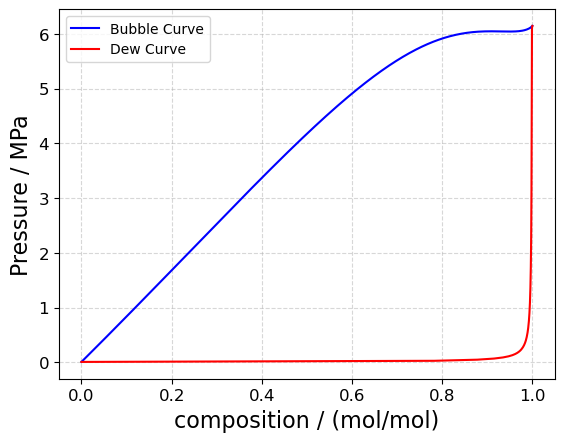

In [8]:
import PyPlot; const plt = PyPlot
using Clapeyron
"""
N = 300
T = 313.15

# 1. Menaikkan rentang batas atas X sedikit (misal ke 0.95 atau 0.98) 
# agar kurva puncak kritisnya bisa terhitung dan menutup sempurna.
x = range(1e-8, 1, length=N)

p = zeros(N)
y = zeros(N)

# Inisialisasi variabel v0 untuk menampung tebakan awal secara kontinu
v0 = []

# 2. Perulangan dengan proteksi try-catch
for j in 1:N
    try
        if j == 1
            # Iterasi pertama menggunakan tebakan default Clapeyron
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]])
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Simpan tebakan awal untuk iterasi berikutnya
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        else
            # Iterasi selanjutnya memanfaatkan nilai v0 dari titik sebelumnya
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]]; v0=v0)
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Perbarui nilai v0 dengan hasil konvergensi terbaru
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        end
    catch e
        # JIKA solver gagal konvergen di dekat titik kritis, titik tersebut 
        # akan diisi dengan NaN (Not a Number) agar kode TIDAK crash/eror,
        # dan grafik Python tetap bisa menggambar bagian yang sukses.
        p[j] = NaN
        y[j] = NaN
    end
end
"""
N    = 401
idxend = N
T    = 298.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_pressure(model, T, [x[i], 1-x[i]])
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_pressure(model, T, [x[i], 1-x[i]]; v0 = v0)
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

# 3. Bagian pembuatan grafik (Plotting)
plt.clf()
plt.plot(x, p./1e6, color="blue", label="Bubble Curve")
plt.plot(y, p./1e6, color="red", label="Dew Curve")
plt.xlabel("composition / (mol/mol)", fontsize=16)
plt.ylabel("Pressure / MPa", fontsize=16)
plt.xlim()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(true, linestyle="--", alpha=0.5) # opsional: menambahkan grid tipis agar rapi

In [9]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [10]:
aard_p   = calculate_AAD(model_opt, "vlep_aceticacid.csv", vle_p)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vlep_aceticacid.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0000      2096.000000   5616.658354   167.9703
0.0344      340000.000000  315372.764530  7.2433  
0.0445      440000.000000  406433.799485  7.6287  
0.0623      600000.000000  567006.932058  5.4988  
0.0688      660000.000000  625664.470716  5.2024  
0.0828      780000.000000  752027.332504  3.5862  
0.1006      940000.000000  912703.614243  2.9039  
0.1227      1140000.000000  1112144.894266  2.4434  
0.1509      1390000.000000  1366393.544876  1.6983  
0.1885      1680000.000000  1704566.223200  1.4623  
0.2315      2040000.000000  2089354.489644  2.4193  
0.2875      2460000.000000  2585473.373256  5.1005  
0.3500      2920000.000000  3128885.920485  7.1536  
0.4127      3390000.000000  3657770.017147  7.8988  
0.4915      3850000.000000  4288265.608215  11.3835 
0.5872      4430000.000000  4976822.163601  12.3436 
0.6834      4970000.000000  5539176.619533  11.4522 
0.7541      5370000.000

15.113548544932955

In [11]:
aard_p   = calculate_AAD(model_opt, "vley_aceticacid.csv", vle_y)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vley_aceticacid.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0344      0.965000      0.981763      1.7371  
0.0445      0.967000      0.985810      1.9452  
0.0623      0.975000      0.989778      1.5157  
0.0688      0.976000      0.990720      1.5082  
0.0828      0.977000      0.992249      1.5608  
0.1006      0.981000      0.993581      1.2825  
0.1227      0.984000      0.994699      1.0873  
0.1509      0.984000      0.995650      1.1839  
0.1885      0.984000      0.996473      1.2676  
0.2315      0.986000      0.997084      1.1242  
0.2875      0.990000      0.997601      0.7678  
0.3500      0.988000      0.997975      1.0096  
0.4127      0.988000      0.998229      1.0353  
0.4915      0.988000      0.998445      1.0572  
0.5872      0.988000      0.998611      1.0740  
0.6834      0.989000      0.998711      0.9819  
0.7541      0.989000      0.998756      0.9865  
AARD = 1.2426%


1.2426337313702294